In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import xgboost as xgb
import matplotlib as plt

In [2]:
train_raw = pd.read_csv('../data/creditcardTrain.csv')
test_raw = pd.read_csv('../data/creditcardTest.csv')
train_raw["is_train"] = 1
test_raw["is_train"] = 0
df = pd.concat([train_raw, test_raw], ignore_index=True)

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month
df["distance_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])

df["gender"] = (df["gender"] == "M").astype(int)
df = pd.get_dummies(df, columns=["category"], dtype=int)

df = df.drop(columns=[
    "Unnamed: 0", "first", "last", "street", "city", "zip", "trans_num",
    "dob", "trans_date_trans_time", "lat", "long", "merch_lat", "merch_long",
])

In [4]:
# Behavioral profile per card, computed causally: only prior transactions for
# that cc_num are used (shift(1) before expanding), so no row ever sees its
# own or a future transaction's amount.
df = df.sort_values(["cc_num", "unix_time"]).reset_index(drop=True)
grp_amt = df.groupby("cc_num")["amt"]
df["card_tx_count"] = grp_amt.cumcount()
df["card_avg_amt_prior"] = grp_amt.transform(lambda s: s.shift(1).expanding().mean()).fillna(0)
df["amt_to_avg_ratio"] = df["amt"] / (df["card_avg_amt_prior"] + 1)

df = df.sort_values("unix_time").reset_index(drop=True)

In [5]:
train = df[df["is_train"] == 1].drop(columns=["is_train"]).copy()
test = df[df["is_train"] == 0].drop(columns=["is_train"]).copy()
train.head()

,cc_num,merchant,amt,gender,state,city_pop,job,unix_time,is_fraud,age,...,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,card_tx_count,card_avg_amt_prior,amt_to_avg_ratio
0,2703186189652095,"fraud_Rippin, Kub and Mann",4.97,0,NC,3495,"Psychologist, counselling",1325376018,0,30.814511,...,0,1,0,0,0,0,0,0,0.0,4.97
1,630423337322,"fraud_Heller, Gutmann and Zieme",107.23,0,WA,149,Special educational needs teacher,1325376044,0,40.531143,...,0,0,0,0,0,0,0,0,0.0,107.23
2,38859492057661,fraud_Lind-Buckridge,220.11,1,ID,4154,Nature conservation officer,1325376051,0,56.950034,...,0,0,0,0,0,0,0,0,0.0,220.11
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.00,1,MT,1939,Patent attorney,1325376076,0,51.969884,...,0,0,0,0,0,0,0,0,0.0,45.00
4,375534208663984,fraud_Keeling-Crist,41.96,1,VA,99,Dance movement psychotherapist,1325376186,0,32.763860,...,0,0,1,0,0,0,0,0,0.0,41.96


In [6]:
# Frequency-encode high-cardinality categoricals. Fit on train only so test
# frequencies (and unseen categories) can't leak into training.
for col in ["merchant", "job", "state"]:
    freq_map = train[col].value_counts(normalize=True)
    train[col + "_freq"] = train[col].map(freq_map)
    test[col + "_freq"] = test[col].map(freq_map).fillna(0)

train = train.drop(columns=["merchant", "job", "state", "cc_num"])
test = test.drop(columns=["merchant", "job", "state", "cc_num"])

In [7]:
X_train = train.drop(columns=["is_fraud"]).copy()
X_test = test.drop(columns=["is_fraud"]).copy()
y_train = train["is_fraud"].copy()
y_test = test["is_fraud"].copy()

In [8]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

clf_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=50,
    scale_pos_weight=ratio,
    learning_rate=0.03,
    n_estimators=1000,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42,
)

In [9]:
clf_xgb.fit(X_train, y_train, verbose=True, eval_set=[(X_test, y_test)])

[0]	validation_0-logloss:0.66862
[1]	validation_0-logloss:0.64517
[2]	validation_0-logloss:0.62286
[3]	validation_0-logloss:0.60182
[4]	validation_0-logloss:0.58140
[5]	validation_0-logloss:0.56321
[6]	validation_0-logloss:0.54648
[7]	validation_0-logloss:0.53010
[8]	validation_0-logloss:0.51424
[9]	validation_0-logloss:0.49808
[10]	validation_0-logloss:0.48245
[11]	validation_0-logloss:0.46765
[12]	validation_0-logloss:0.45335
[13]	validation_0-logloss:0.43949
[14]	validation_0-logloss:0.42731
[15]	validation_0-logloss:0.41521
[16]	validation_0-logloss:0.40416
[17]	validation_0-logloss:0.39370
[18]	validation_0-logloss:0.38240
[19]	validation_0-logloss:0.37226
[20]	validation_0-logloss:0.36224
[21]	validation_0-logloss:0.35335
[22]	validation_0-logloss:0.34456
[23]	validation_0-logloss:0.33550
[24]	validation_0-logloss:0.32700
[25]	validation_0-logloss:0.31889
[26]	validation_0-logloss:0.31111
[27]	validation_0-logloss:0.30353
[28]	validation_0-logloss:0.29595
[29]	validation_0-loglos

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
print(clf_xgb.best_iteration)                        
print(clf_xgb.get_booster().num_boosted_rounds()) 

999
1000


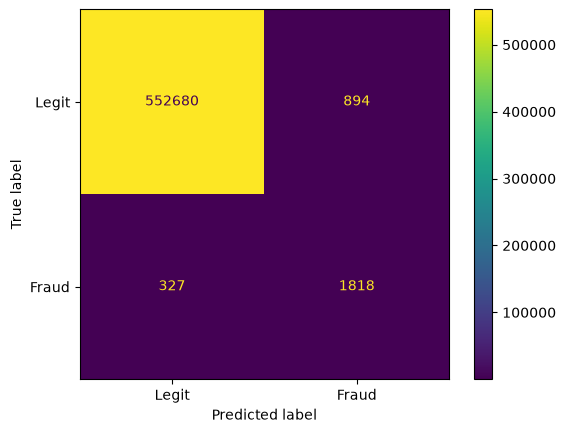

In [11]:
ConfusionMatrixDisplay.from_estimator(clf_xgb, X_test, y_test, display_labels=['Legit','Fraud'])

In [12]:
clf_xgb.save_model("../artifacts/heimdall_fraud_model.json")